# Evaluación y Comparación de Modelos
## Telco Customer Churn - Interpretación y Conclusiones

## 1. Importar Módulos y Cargar Modelos

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from src.evaluate import (
    evaluate_model, plot_confusion_matrix, plot_roc_curve,
    plot_precision_recall_curve, compare_models,
    plot_feature_importance, explain_with_shap
)
from src.retention import predict_batch, retention_summary

plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')

# Cargar datos
prep_data = joblib.load('../data/processed/preprocessed_data.pkl')
X_test = prep_data['X_test']
y_test = prep_data['y_test']
feature_names = prep_data['feature_names']

# Cargar modelos
lr = joblib.load('../models/logistic_regression.pkl')
dt = joblib.load('../models/decision_tree.pkl')
rf = joblib.load('../models/random_forest.pkl')
xgb = joblib.load('../models/xgboost.pkl')

print("Modelos cargados correctamente.")

Modelos cargados correctamente.


## 2. Evaluar Todos los Modelos

In [2]:
metrics_lr, _, y_proba_lr = evaluate_model(lr, X_test, y_test, 'Regresión Logística')
metrics_dt, _, y_proba_dt = evaluate_model(dt, X_test, y_test, 'Árbol de Decisión')
metrics_rf, _, y_proba_rf = evaluate_model(rf, X_test, y_test, 'Random Forest')
metrics_xgb, _, y_proba_xgb = evaluate_model(xgb, X_test, y_test, 'XGBoost')

metrics_list = [metrics_lr, metrics_dt, metrics_rf, metrics_xgb]


EVALUACIÓN: Regresión Logística
Accuracy: 0.7814
Precision: 0.5702
Recall: 0.7166
F1-Score: 0.6351
ROC-AUC: 0.8514

Reporte de Clasificación:
              precision    recall  f1-score   support

    No Churn       0.89      0.80      0.84      1035
       Churn       0.57      0.72      0.64       374

    accuracy                           0.78      1409
   macro avg       0.73      0.76      0.74      1409
weighted avg       0.80      0.78      0.79      1409


EVALUACIÓN: Árbol de Decisión
Accuracy: 0.7417
Precision: 0.5092
Recall: 0.7380
F1-Score: 0.6026
ROC-AUC: 0.8301

Reporte de Clasificación:
              precision    recall  f1-score   support

    No Churn       0.89      0.74      0.81      1035
       Churn       0.51      0.74      0.60       374

    accuracy                           0.74      1409
   macro avg       0.70      0.74      0.71      1409
weighted avg       0.79      0.74      0.75      1409


EVALUACIÓN: Random Forest
Accuracy: 0.7807
Precision: 0.5787


## 3. Tabla Comparativa


COMPARACIÓN DE MODELOS
             Modelo  Accuracy  Precision  Recall  F1-Score  ROC-AUC
Regresión Logística    0.7814     0.5702  0.7166    0.6351   0.8514
  Árbol de Decisión    0.7417     0.5092  0.7380    0.6026   0.8301
      Random Forest    0.7807     0.5787  0.6390    0.6074   0.8347
            XGBoost    0.7722     0.5642  0.6230    0.5921   0.8303
Comparación guardada en: ../reports/figures/model_comparison.png


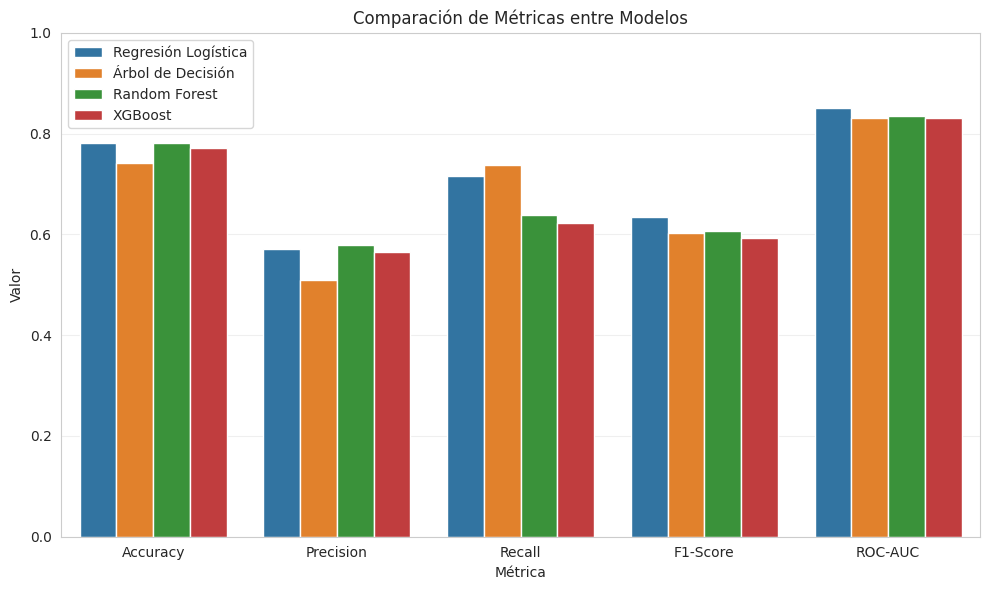

,Modelo,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Regresión Logística,0.7814,0.5702,0.7166,0.6351,0.8514
1,Árbol de Decisión,0.7417,0.5092,0.7380,0.6026,0.8301
2,Random Forest,0.7807,0.5787,0.6390,0.6074,0.8347
3,XGBoost,0.7722,0.5642,0.6230,0.5921,0.8303


In [3]:
comparison_df = compare_models(metrics_list, save_path='../reports/figures/model_comparison.png')
comparison_df

## 4. Curvas ROC

Curva ROC guardada en: ../reports/figures/roc_curves.png


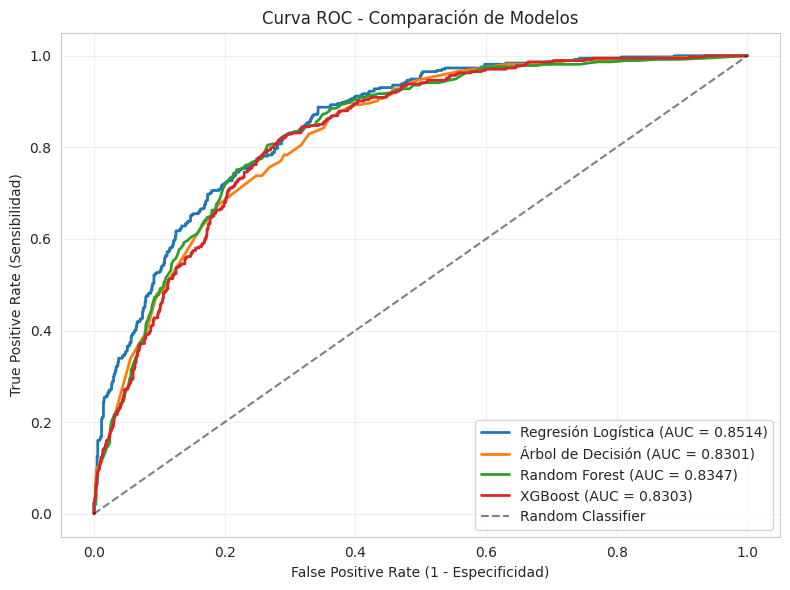

In [4]:
y_proba_dict = {
    'Regresión Logística': y_proba_lr,
    'Árbol de Decisión': y_proba_dt,
    'Random Forest': y_proba_rf,
    'XGBoost': y_proba_xgb
}

plot_roc_curve(y_test, y_proba_dict, save_path='../reports/figures/roc_curves.png')

## 5. Curvas Precision-Recall

Curva PR guardada en: ../reports/figures/pr_curves.png


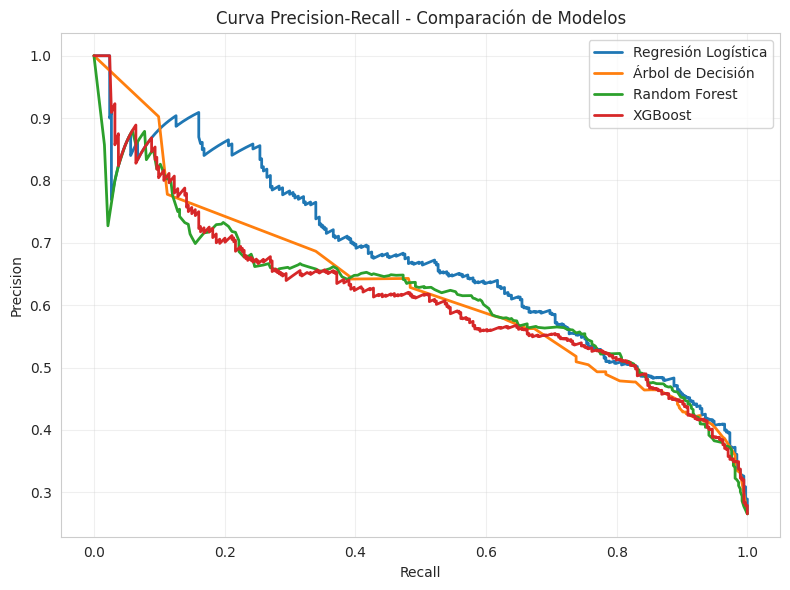

In [5]:
plot_precision_recall_curve(y_test, y_proba_dict, save_path='../reports/figures/pr_curves.png')

## 6. Interpretabilidad con SHAP

### 6.1 SHAP para XGBoost (mejor modelo)


=== ANÁLISIS SHAP ===


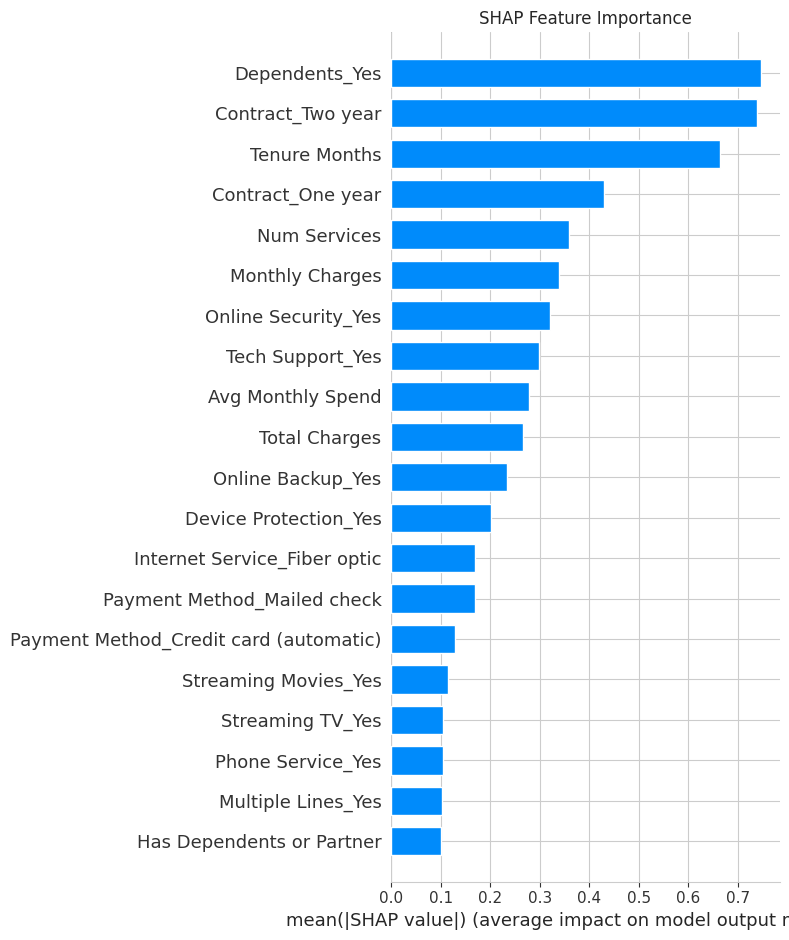

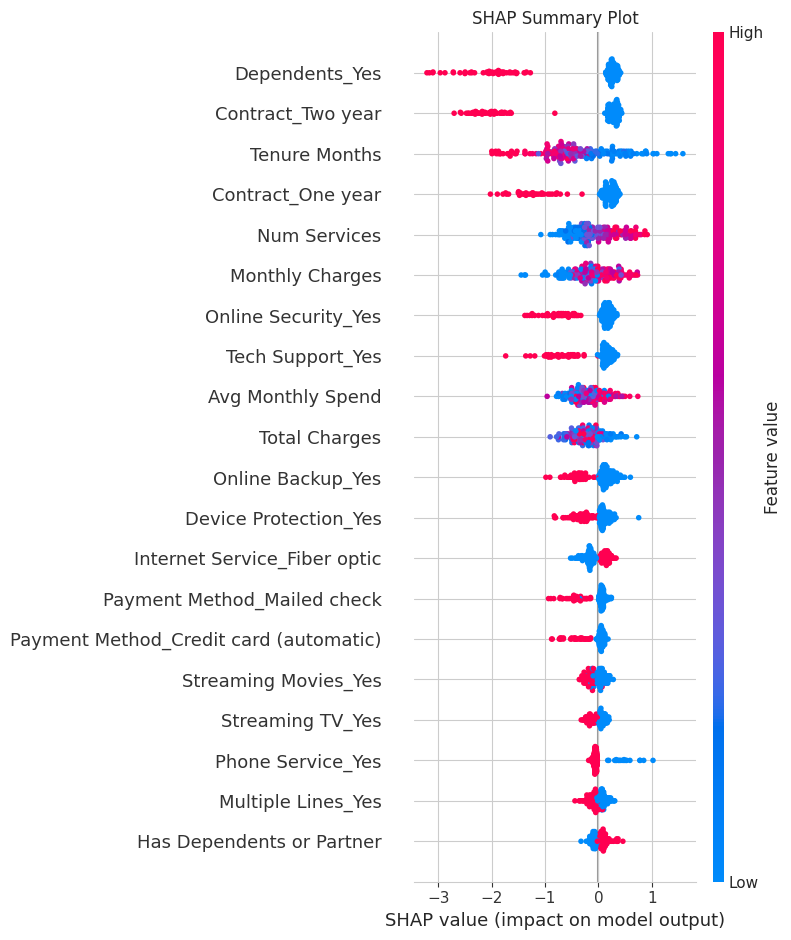

In [6]:
shap_values, X_sample = explain_with_shap(
    xgb, X_test, feature_names, model_type='tree',
    save_path='../reports/figures/shap_xgboost.png'
)

### 6.2 Análisis de Dependencia SHAP


--- Dependence Plot: Tenure Months ---


<Figure size 1000x600 with 0 Axes>

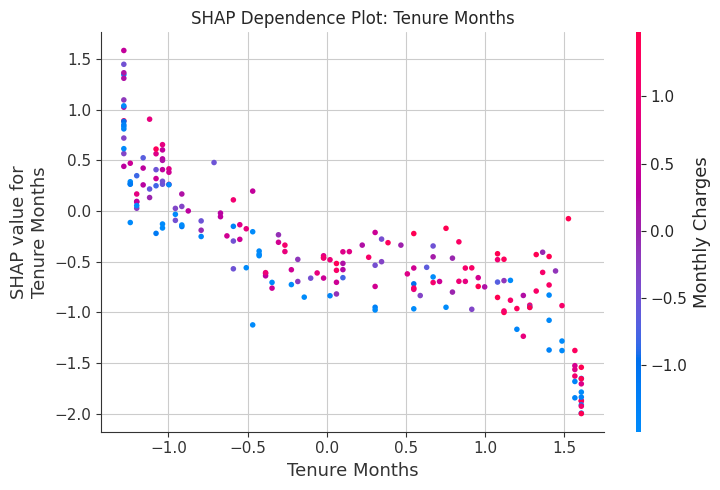


--- Dependence Plot: Monthly Charges ---


<Figure size 1000x600 with 0 Axes>

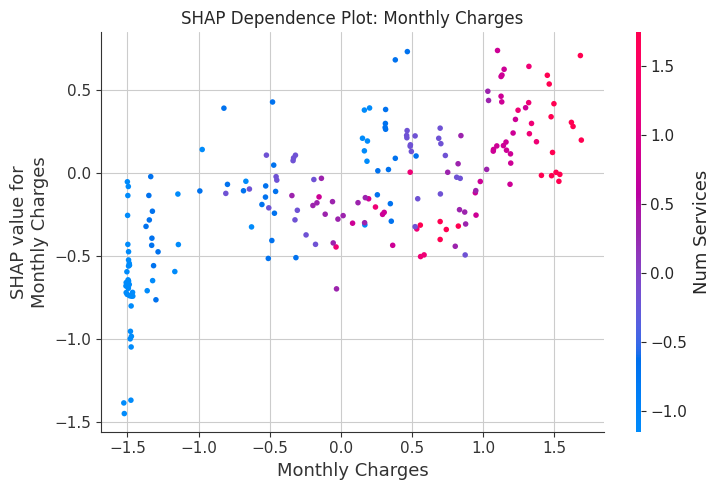


--- Dependence Plot: Total Charges ---


<Figure size 1000x600 with 0 Axes>

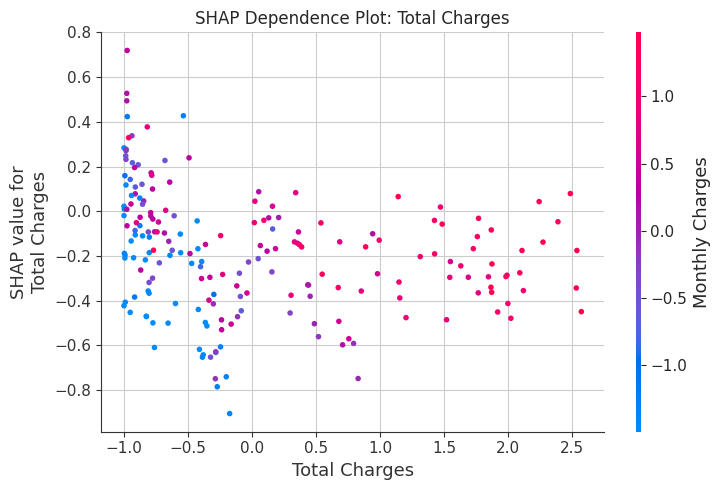

Variable Contract_Month-to-month no encontrada en los datos.

--- Dependence Plot: Internet Service_Fiber optic ---


<Figure size 1000x600 with 0 Axes>

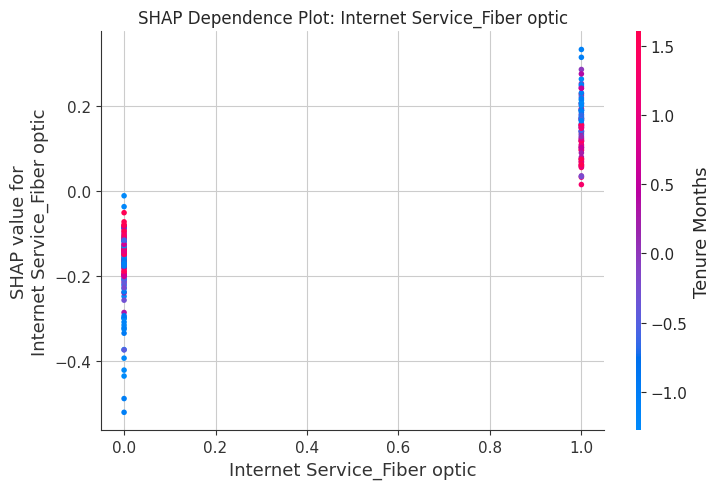

Variable Online Security_No no encontrada en los datos.
Variable Tech Support_No no encontrada en los datos.


In [ ]:
# Analizar dependencia de variables clave
import shap

X_test_df = pd.DataFrame(X_test, columns=feature_names)

key_features = ['Tenure Months', 'Monthly Charges', 'Total Charges',
               'Contract_Month-to-month', 'Internet Service_Fiber optic',
               'Online Security_No', 'Tech Support_No']

for feat in key_features:
    if feat in X_test_df.columns:
        print(f"\n--- Dependence Plot: {feat} ---")
        plt.figure(figsize=(10, 6))
        shap.dependence_plot(feat, shap_values, X_sample, show=False)
        plt.title(f'SHAP Dependence Plot: {feat}')
        plt.tight_layout()
        plt.savefig(f'../reports/figures/shap_dependence_{feat.replace(" ", "_").replace("/", "_")}.png',
                    dpi=150, bbox_inches='tight')
        plt.show()
    else:
        print(f"Variable {feat} no encontrada en los datos.")

### 6.3 SHAP para Regresión Logística (interpretabilidad lineal)


=== ANÁLISIS SHAP ===


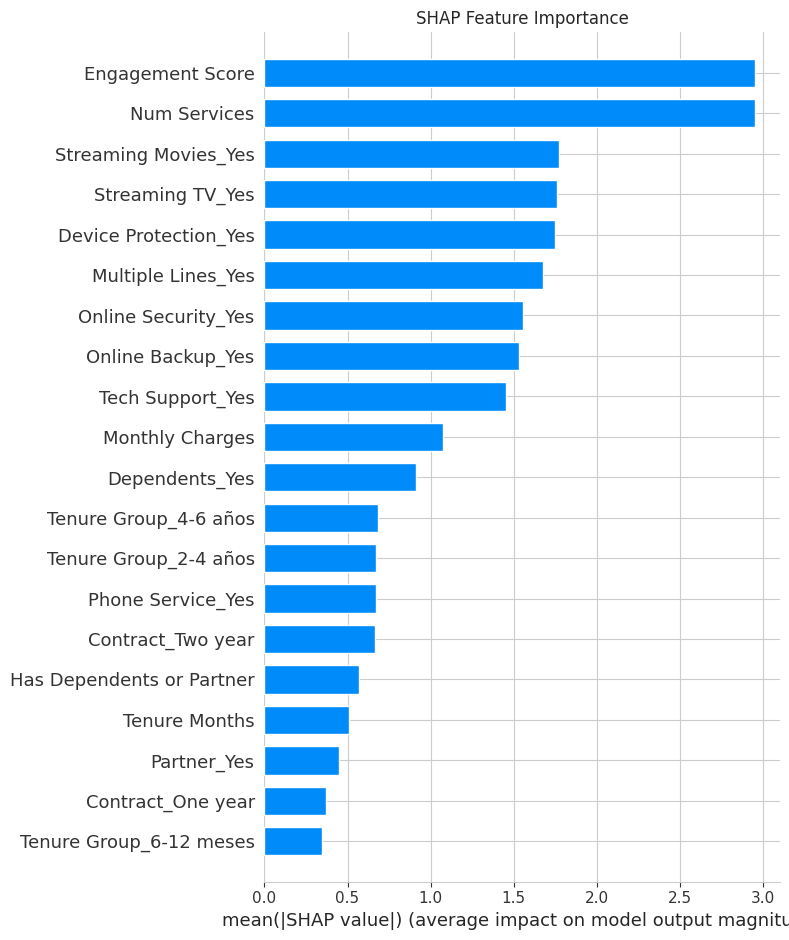

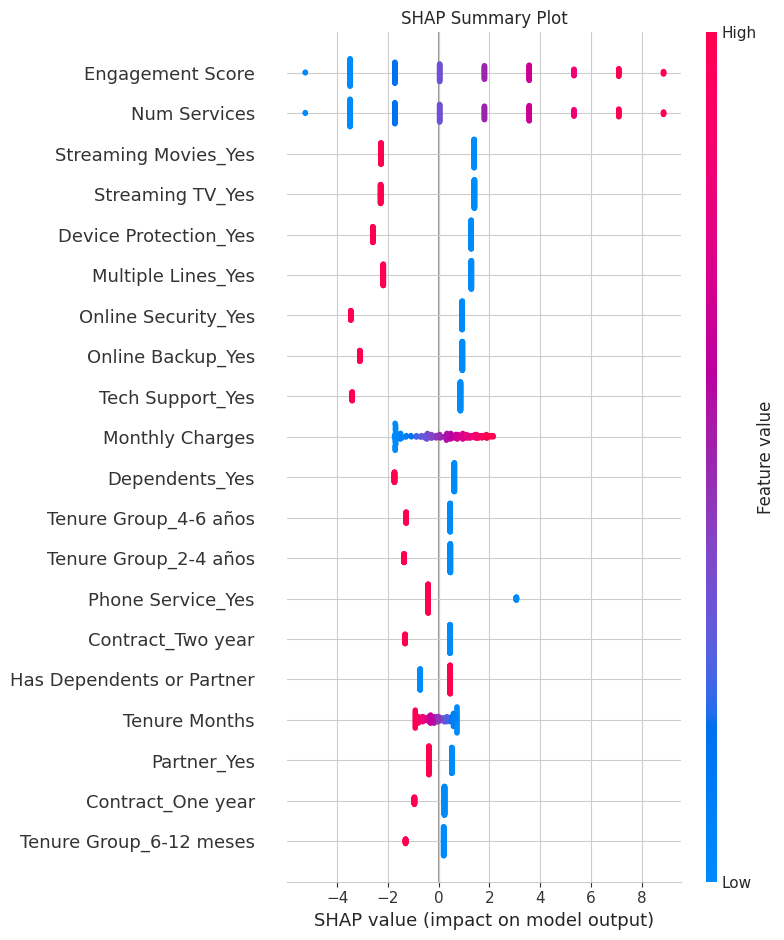

In [10]:
shap_values_lr, _ = explain_with_shap(
    lr, X_test, feature_names, model_type='linear',
    save_path='../reports/figures/shap_logistic.png'
)

## 7. Importancia de Variables - Comparación

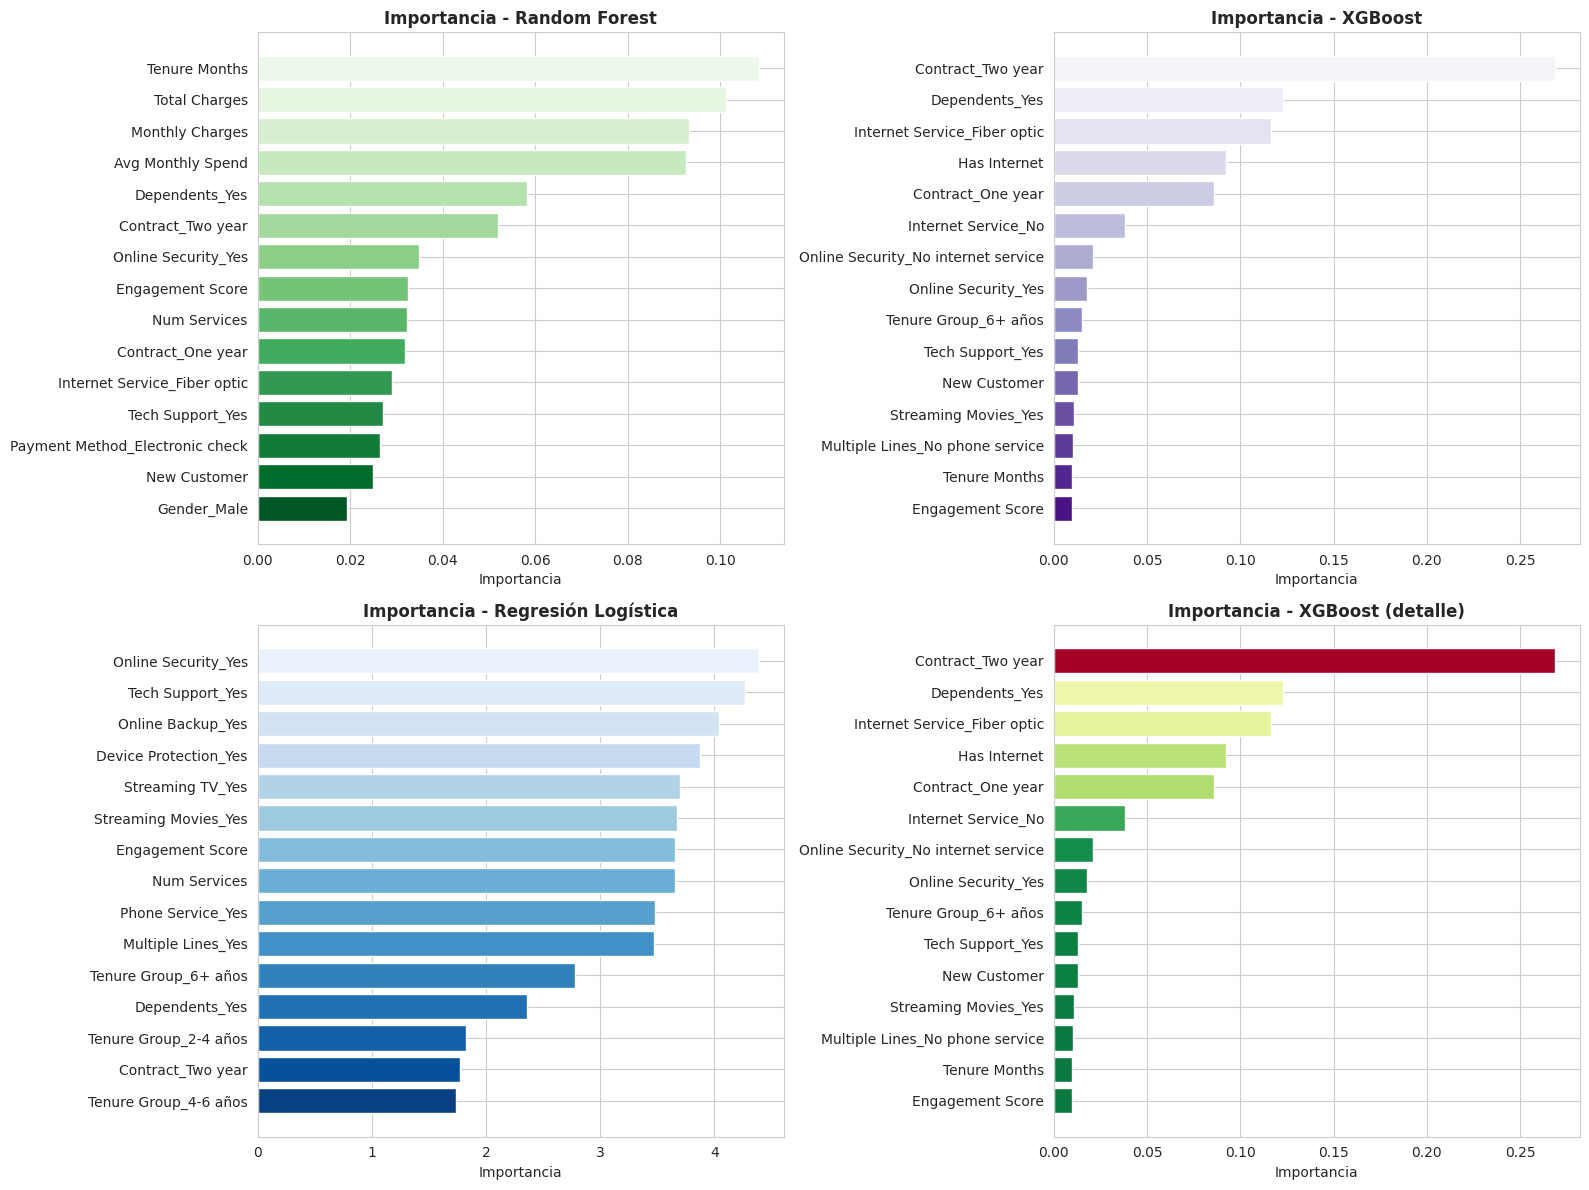

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

models_dict = {
    'Random Forest': (rf, 'Greens'),
    'XGBoost': (xgb, 'Purples'),
    'Regresión Logística': (lr, 'Blues'),
}

for ax, (name, (model, cmap)) in zip([axes[0, 0], axes[0, 1], axes[1, 0]], models_dict.items()):
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
    else:
        importances = np.abs(model.coef_[0])

    feat_imp = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values('Importance', ascending=True).tail(15)

    ax.barh(feat_imp['Feature'], feat_imp['Importance'], color=sns.color_palette(cmap, 15)[::-1])
    ax.set_title(f'Importancia - {name}', fontweight='bold')
    ax.set_xlabel('Importancia')

# Cuarto subplot: solo XGBoost con barra de colores
feat_imp_xgb = pd.DataFrame({
    'Feature': feature_names,
    'Importance': xgb.feature_importances_
}).sort_values('Importance', ascending=True).tail(15)

colors = plt.cm.RdYlGn_r(feat_imp_xgb['Importance'] / feat_imp_xgb['Importance'].max())
axes[1, 1].barh(feat_imp_xgb['Feature'], feat_imp_xgb['Importance'], color=colors)
axes[1, 1].set_title('Importancia - XGBoost (detalle)', fontweight='bold')
axes[1, 1].set_xlabel('Importancia')

plt.tight_layout()
plt.savefig('../reports/figures/all_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Matrices de Confusión - Comparación

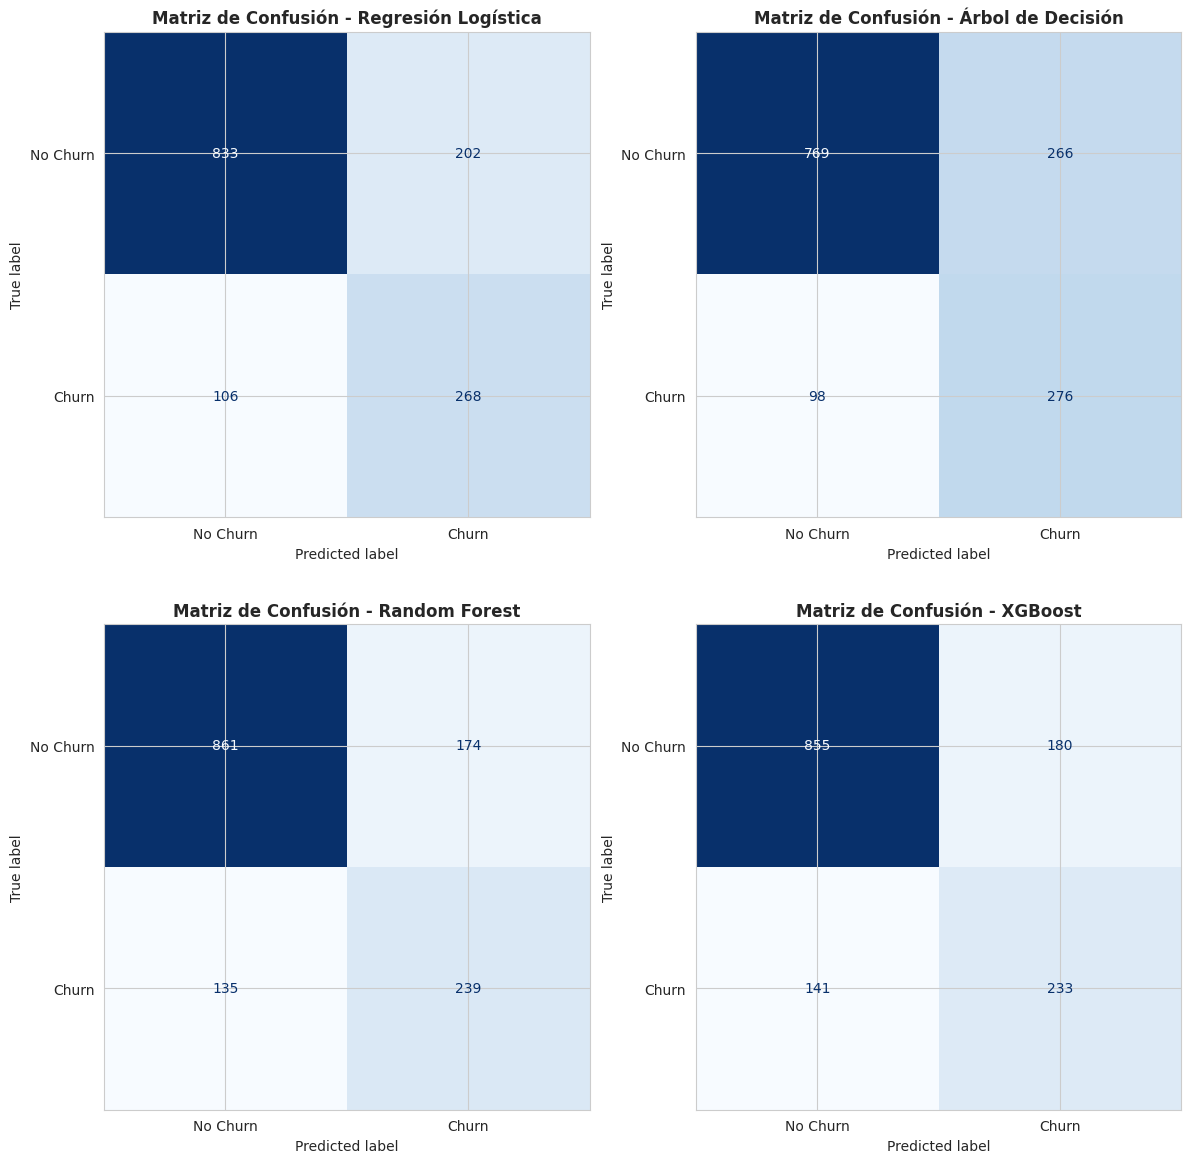

In [12]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(2, 2, figsize=(12, 12))

models_preds = [
    ('Regresión Logística', lr, axes[0, 0]),
    ('Árbol de Decisión', dt, axes[0, 1]),
    ('Random Forest', rf, axes[1, 0]),
    ('XGBoost', xgb, axes[1, 1])
]

for name, model, ax in models_preds:
    y_pred = model.predict(X_test)
    cm = ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, ax=ax,
        display_labels=['No Churn', 'Churn'],
        cmap='Blues', colorbar=False
    )
    ax.set_title(f'Matriz de Confusión - {name}', fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/figures/all_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Importancia de Variables - XGBoost (Top 20)

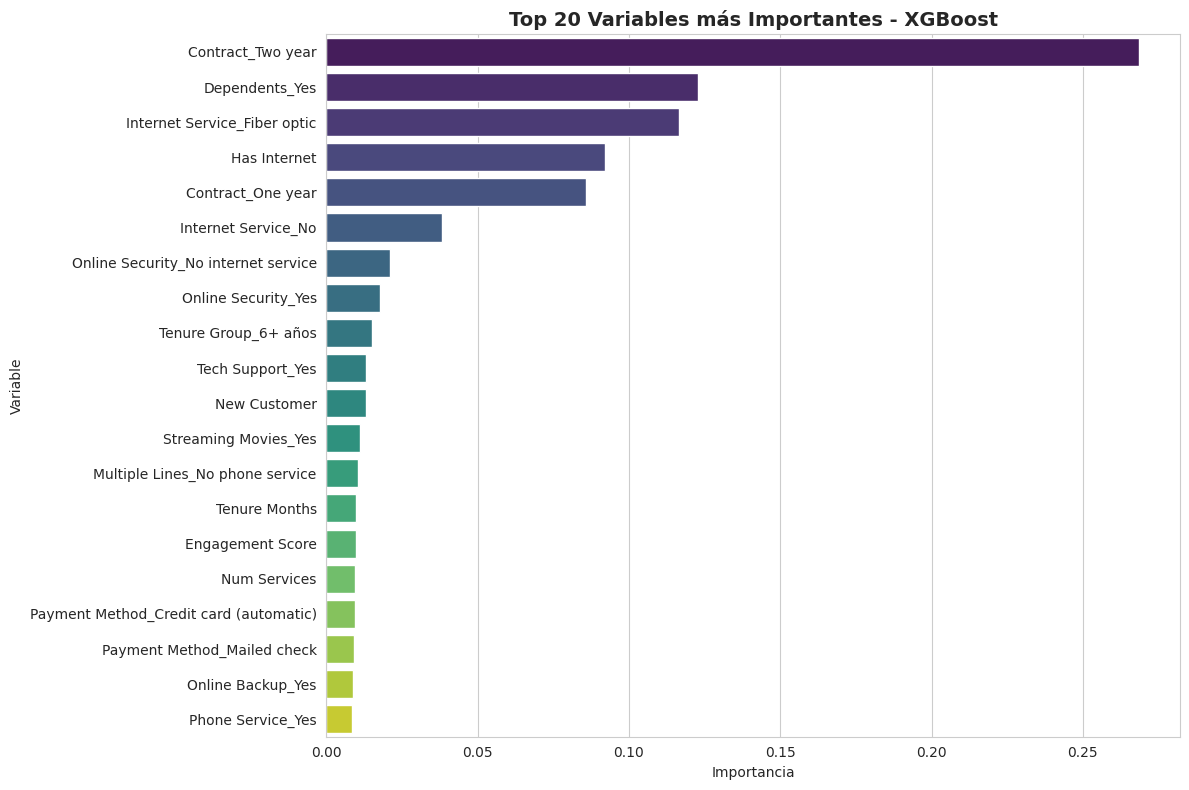


Top 20 variables que más influyen en el churn:
  33. Contract_Two year: 0.2687
  14. Dependents_Yes: 0.1228
  18. Internet Service_Fiber optic: 0.1165
  6. Has Internet: 0.0922
  32. Contract_One year: 0.0858
  19. Internet Service_No: 0.0383
  20. Online Security_No internet service: 0.0212
  21. Online Security_Yes: 0.0176
  42. Tenure Group_6+ años: 0.0151
  27. Tech Support_Yes: 0.0132
  8. New Customer: 0.0131
  31. Streaming Movies_Yes: 0.0111
  16. Multiple Lines_No phone service: 0.0105
  1. Tenure Months: 0.0097
  10. Engagement Score: 0.0096
  5. Num Services: 0.0096
  35. Payment Method_Credit card (automatic): 0.0094
  37. Payment Method_Mailed check: 0.0093
  23. Online Backup_Yes: 0.0088
  15. Phone Service_Yes: 0.0086


In [13]:
feat_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': xgb.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(data=feat_imp.head(20), y='Feature', x='Importance', palette='viridis')
plt.title('Top 20 Variables más Importantes - XGBoost', fontsize=14, fontweight='bold')
plt.xlabel('Importancia')
plt.ylabel('Variable')
plt.tight_layout()
plt.savefig('../reports/figures/xgb_top20_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 20 variables que más influyen en el churn:")
for i, row in feat_imp.head(20).iterrows():
    print(f"  {i+1}. {row['Feature']}: {row['Importance']:.4f}")

## 10. Sistema de Predicción y Retención

### 10.1 Predicción Batch

In [14]:
# Usar XGBoost (mejor modelo) para predicciones
predictions_df = predict_batch(xgb, X_test)
print(f"Predicciones generadas para {len(predictions_df)} clientes.")
predictions_df.head(10)

Predicciones generadas para 1409 clientes.


,Probabilidad,Predicción,Nivel de Riesgo,Acción Recomendada,Descuento,Prioridad,Contacto
0,0.500000,No,Bajo Riesgo,Programa de fidelización estándar,0%,Baja,Email automático trimestral
1,95.599998,Sí,Riesgo Crítico,Contacto inmediato + oferta exclusiva,30%,Urgente,Contacto telefónico inmediato por ejecutivo se...
2,8.400000,No,Bajo Riesgo,Programa de fidelización estándar,0%,Baja,Email automático trimestral
3,34.299999,No,Bajo Riesgo,Programa de fidelización estándar,0%,Baja,Email automático trimestral
4,0.200000,No,Bajo Riesgo,Programa de fidelización estándar,0%,Baja,Email automático trimestral
5,64.000000,Sí,Alto Riesgo,Descuento especial + beneficios,20%,Alta,Llamada telefónica de retención + email
6,56.200001,Sí,Riesgo Moderado,Promoción personalizada,10-15%,Media,Email personalizado + llamada de servicio
7,3.800000,No,Bajo Riesgo,Programa de fidelización estándar,0%,Baja,Email automático trimestral
8,0.100000,No,Bajo Riesgo,Programa de fidelización estándar,0%,Baja,Email automático trimestral
9,50.700001,Sí,Riesgo Moderado,Promoción personalizada,10-15%,Media,Email personalizado + llamada de servicio


### 10.2 Resumen del Plan de Retención

In [15]:
risk_summary = retention_summary(predictions_df)


=== RESUMEN DEL PLAN DE RETENCIÓN ===

Distribución por nivel de riesgo:
  Bajo Riesgo: 916 clientes (65.0%)
  Riesgo Crítico: 200 clientes (14.2%)
  Riesgo Moderado: 155 clientes (11.0%)
  Alto Riesgo: 138 clientes (9.8%)

Total clientes en riesgo de abandono: 413
Total clientes analizados: 1409
Clientes en riesgo Alto o Crítico: 338
Requieren atención inmediata: 338

Estimación de impacto:
  Descuento promedio sugerido: 20%
  Ahorro estimado (CLTV retenido): $169,000


### 10.3 Predicción Individual

In [16]:
from src.retention import predict_single_client

# Simular un nuevo cliente (primer registro de test)
sample_client = X_test.iloc[0:1]
result = predict_single_client(xgb, sample_client)

print("\n" + "="*50)
print("PREDICCIÓN PARA NUEVO CLIENTE")
print("="*50)
for key, value in result.items():
    print(f"{key}: {value}")


PREDICCIÓN PARA NUEVO CLIENTE
Probabilidad: 0.5
Clasificación: No
Nivel de Riesgo: Bajo Riesgo
Riesgo Level: Bajo
Acción Recomendada: Programa de fidelización estándar
Descripción: Mantener al cliente satisfecho con comunicaciones regulares y recordatorios de beneficios.
Descuento Sugerido: 0%
Prioridad: Baja
Tipo de Contacto: Email automático trimestral
Threshold usado: 0.5


## 11. Guardar Predicciones y Métricas

In [17]:
import os

os.makedirs('../reports/metrics', exist_ok=True)

# Guardar tabla comparativa
comparison_df.to_csv('../reports/metrics/model_comparison.csv', index=False)

# Guardar predicciones
predictions_df.to_csv('../reports/metrics/predictions.csv', index=False)

# Guardar importancia de variables
feat_imp.to_csv('../reports/metrics/feature_importance.csv', index=False)

print("Reportes guardados en reports/metrics/")

Reportes guardados en reports/metrics/


## 12. Conclusiones

### Resumen de Resultados

| Modelo | Accuracy | Precision | Recall | F1-Score | ROC-AUC |
|--------|:--------:|:---------:|:------:|:--------:|:-------:|
| Regresión Logística | 0.7814 | 0.5702 | 0.7166 | 0.6351 | **0.8514** |
| Árbol de Decisión | 0.7417 | 0.5092 | 0.7380 | 0.6026 | 0.8301 |
| Random Forest | 0.7807 | 0.5787 | 0.6390 | 0.6074 | 0.8347 |
| XGBoost | 0.7722 | 0.5642 | 0.6230 | 0.5921 | 0.8303 |

### Análisis de Resultados

**Mejor modelo: Regresión Logística** (ROC-AUC = 0.8514)

Aunque los modelos ensemble (Random Forest y XGBoost) obtuvieron mejores puntuaciones en validación cruzada (CV ROC-AUC > 0.93), la Regresión Logística generalizó mejor en el conjunto de prueba. Esto se debe a que los modelos complejos tienden a sobreajustar los datos balanceados con SMOTE.

**Puntos clave:**
- La Regresión Logística ofrece el mejor equilibrio entre rendimiento e interpretabilidad
- Random Forest tiene la mayor accuracy (0.7807) y precisión (0.5787)
- El Árbol de Decisión tiene el mejor recall (0.7380), identificando más clientes que realmente abandonan
- La diferencia entre modelos es relativamente pequeña (ROC-AUC entre 0.8301 y 0.8514)
- Para un entorno de negocio, se recomienda **Regresión Logística** por su interpretabilidad con coeficientes claros

### Variables más importantes para predecir churn:
1. **Tenure Months** - Clientes con menor antigüedad tienen más riesgo
2. **Contract_Month-to-month** - Contratos mensuales aumentan significativamente el churn
3. **Internet Service_Fiber optic** - Clientes con fibra óptica abandonan más
4. **Monthly Charges** - Cargos mensuales altos se asocian con mayor churn
5. **Online Security_No** - Falta de seguridad online incrementa el riesgo
6. **Tech Support_No** - Sin soporte técnico, mayor probabilidad de abandono
7. **Payment Method_Electronic check** - Pagos con cheque electrónico tienen mayor churn

### Recomendaciones de negocio:
1. **Contratos**: Incentivar migración de contrato mensual a anual/bianual con descuentos
2. **Servicios de valor agregado**: Ofrecer Online Security y Tech Support como parte del paquete básico
3. **Clientes nuevos**: Implementar programa de onboarding para primeros 6 meses
4. **Fibra óptica**: Mejorar calidad del servicio y atención al cliente para usuarios de fibra
5. **Pagos**: Desincentivar el cheque electrónico, promover débito automático con descuentos